# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
from io import StringIO

import pandas as pd
import requests
import matplotlib.pyplot as plt

# You can use example datasets here docs/example_datasets.md

print(f"Current folder: {os.path.basename(os.getcwd())}")
print(f"Files in current folder: {os.listdir()}")

# 2. Acquire and load your primary dataset
tracker_url = "https://www.enforcementtracker.com/"
request_headers = {"User-Agent": "Mozilla/5.0"}

tracker_response = requests.get(tracker_url, headers=request_headers)
tracker_response.raise_for_status()
tracker_response.encoding = "utf-8"

start_marker = '<script type="application/json" id="et-cases" data-purpose="filter-bootstrap">'
end_marker = "</script>"
start_index = tracker_response.text.find(start_marker) + len(start_marker)
end_index = tracker_response.text.find(end_marker, start_index)
tracker_json = tracker_response.text[start_index:end_index]

df_gdpr_raw = pd.read_json(StringIO(tracker_json))

df_gdpr_raw.head()

Current folder: hw_3
Files in current folder: ['chelyukanova-daria-hw3.ipynb']


,e,c,C,F,a,d,y,f,p,s,r,t,u
0,1,AUSTRIA,Austria,/flags/flag_austria.png,Austrian Data Protection Authority (dsb),2018-12-09,2018.0,4800.0,Betting place,Industry and Commerce,Art. 13 GDPR,Insufficient fulfilment of information obligat...,https://www.dsb.gv.at/documents/22758/116802/S...
1,2,AUSTRIA,Austria,/flags/flag_austria.png,Austrian Data Protection Authority (dsb),2018,2018.0,1800.0,Kebab restaurant,Accomodation and Hospitality,"Art. 5 GDPR, Art. 13 GDPR, Art. 14 GDPR",Insufficient legal basis for data processing,https://www.dsb.gv.at/documents/22758/115212/N...
2,3,AUSTRIA,Austria,/flags/flag_austria.png,Austrian Data Protection Authority (dsb),2018-09-27,2018.0,300.0,Private car owner,Individuals and Private Associations,"Art. 5 (1) a) GDPR, Art. 6 GDPR",Insufficient legal basis for data processing,https://www.ris.bka.gv.at/Dokumente/Dsk/DSBT_2...
3,4,AUSTRIA,Austria,/flags/flag_austria.png,Austrian Data Protection Authority (dsb),2018-12-20,2018.0,2200.0,Private person,Individuals and Private Associations,"Art. 5 (1) a) GDPR, Art. 5 (1) c) GDPR, Art. 6...",Insufficient legal basis for data processing,https://www.ris.bka.gv.at/Dokumente/Dsk/DSBT_2...
4,5,BELGIUM,Belgium,/flags/flag_belgium.png,Belgian Data Protection Authority (APD),2019-05-28,2019.0,2000.0,Mayor,Public Sector and Education,"Art. 5 (1) b) GDPR, Art. 6 GDPR",Insufficient legal basis for data processing,https://www.autoriteprotectiondonnees.be/news/...


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- First dataset: **GDPR Enforcement Tracker** - CMS

https://www.enforcementtracker.com


- Second Dataset: **European Innovation Index** - European Commission

https://projects.research-and-innovation.ec.europa.eu/en/statistics/performance-indicators/european-innovation-scoreboard/eis#/eis

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1 Inspect data structure using pandas method
# 1.1 Inspecting table

df_gdpr_raw.head()


,e,c,C,F,a,d,y,f,p,s,r,t,u
0,1,AUSTRIA,Austria,/flags/flag_austria.png,Austrian Data Protection Authority (dsb),2018-12-09,2018.0,4800.0,Betting place,Industry and Commerce,Art. 13 GDPR,Insufficient fulfilment of information obligat...,https://www.dsb.gv.at/documents/22758/116802/S...
1,2,AUSTRIA,Austria,/flags/flag_austria.png,Austrian Data Protection Authority (dsb),2018,2018.0,1800.0,Kebab restaurant,Accomodation and Hospitality,"Art. 5 GDPR, Art. 13 GDPR, Art. 14 GDPR",Insufficient legal basis for data processing,https://www.dsb.gv.at/documents/22758/115212/N...
2,3,AUSTRIA,Austria,/flags/flag_austria.png,Austrian Data Protection Authority (dsb),2018-09-27,2018.0,300.0,Private car owner,Individuals and Private Associations,"Art. 5 (1) a) GDPR, Art. 6 GDPR",Insufficient legal basis for data processing,https://www.ris.bka.gv.at/Dokumente/Dsk/DSBT_2...
3,4,AUSTRIA,Austria,/flags/flag_austria.png,Austrian Data Protection Authority (dsb),2018-12-20,2018.0,2200.0,Private person,Individuals and Private Associations,"Art. 5 (1) a) GDPR, Art. 5 (1) c) GDPR, Art. 6...",Insufficient legal basis for data processing,https://www.ris.bka.gv.at/Dokumente/Dsk/DSBT_2...
4,5,BELGIUM,Belgium,/flags/flag_belgium.png,Belgian Data Protection Authority (APD),2019-05-28,2019.0,2000.0,Mayor,Public Sector and Education,"Art. 5 (1) b) GDPR, Art. 6 GDPR",Insufficient legal basis for data processing,https://www.autoriteprotectiondonnees.be/news/...


In [3]:
# 1.2 Inspecting columns

df_gdpr_raw.info()
df_gdpr_raw.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3195 entries, 0 to 3194
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   e       3195 non-null   int64  
 1   c       3195 non-null   object 
 2   C       3195 non-null   object 
 3   F       3195 non-null   object 
 4   a       3195 non-null   object 
 5   d       3195 non-null   object 
 6   y       3172 non-null   float64
 7   f       3061 non-null   float64
 8   p       3195 non-null   object 
 9   s       3195 non-null   object 
 10  r       3195 non-null   object 
 11  t       3195 non-null   object 
 12  u       3194 non-null   object 
dtypes: float64(2), int64(1), object(10)
memory usage: 324.6+ KB


Index(['e', 'c', 'C', 'F', 'a', 'd', 'y', 'f', 'p', 's', 'r', 't', 'u'], dtype='object')

In [4]:
# 1.3 Inspecting unique country values

df_gdpr_raw["c"].unique()

array(['AUSTRIA', 'BELGIUM', 'BULGARIA', 'CYPRUS', 'CZECH REPUBLIC',
       'DENMARK', 'FRANCE', 'GERMANY', 'HUNGARY', 'ITALY', 'LITHUANIA',
       'MALTA', 'NORWAY', 'POLAND', 'PORTUGAL', 'SPAIN', 'ROMANIA',
       'UNITED KINGDOM', 'THE NETHERLANDS', 'GREECE', 'SWEDEN', 'LATVIA',
       'SLOVAKIA', 'ICELAND', 'CROATIA', 'IRELAND', 'FINLAND', 'ESTONIA',
       'ISLE OF MAN', 'LUXEMBOURG', 'LIECHTENSTEIN', 'SLOVENIA'],
      dtype=object)

In [5]:
# 1.4 Inspecting unique year values
df_gdpr_raw["y"].unique()

array([2018., 2019.,   nan, 2021., 2020., 2022., 2023., 2024., 2025.,
       2026.])

In [6]:
# 1.5 Inspecting unique sector values
df_gdpr_raw["s"].unique()

array(['Industry and Commerce', 'Accomodation and Hospitality',
       'Individuals and Private Associations',
       'Public Sector and Education', 'Finance, Insurance and Consulting',
       'Media, Telecoms and Broadcasting', 'Employment', 'Health Care',
       'Not assigned', 'Transportation and Energy', 'Real Estate'],
      dtype=object)

In [7]:
# 1.6 Inspecting unique types of violation
df_gdpr_raw["t"].unique()

array(['Insufficient fulfilment of information obligations',
       'Insufficient legal basis for data processing',
       'Insufficient fulfilment of data subjects rights',
       'Insufficient technical and organisational measures to ensure information security',
       'Non-compliance with general data processing principles',
       'Insufficient data processing agreement',
       'Insufficient fulfilment of data breach notification obligations',
       'Unknown', 'Insufficient cooperation with supervisory authority',
       'Insufficient involvement of data protection officer',
       'Lack of appointment of data protection officer'], dtype=object)

In [8]:
# 1.7 Checking the range of fine values
df_gdpr_raw["f"] = df_gdpr_raw["f"].astype("Int64")
df_gdpr_raw["f"].describe()

count             3061.0
mean      2060421.418164
std      29388080.796219
min                  0.0
25%               2000.0
50%               8000.0
75%              45000.0
max         1200000000.0
Name: f, dtype: Float64

In [9]:
# 2. Rename columns and select a clean subset

df_gdpr = df_gdpr_raw.rename(columns={"C": "Country", "y": "Year", "f" : "Fine", "s" : "Sector", "t" : "Violation_Type"})
df_gdpr = df_gdpr.drop(columns=["a", "d", "e", "c", "F", "p", "r", "u"])
df_gdpr.head()

,Country,Year,Fine,Sector,Violation_Type
0,Austria,2018.0,4800,Industry and Commerce,Insufficient fulfilment of information obligat...
1,Austria,2018.0,1800,Accomodation and Hospitality,Insufficient legal basis for data processing
2,Austria,2018.0,300,Individuals and Private Associations,Insufficient legal basis for data processing
3,Austria,2018.0,2200,Individuals and Private Associations,Insufficient legal basis for data processing
4,Belgium,2019.0,2000,Public Sector and Education,Insufficient legal basis for data processing


In [10]:
# 3. Filter row or column filters if necessary

# Fine amount and count per country per year
df_gdpr["Year"] = df_gdpr["Year"].astype("Int64")
df_gdpr["Fine"] = df_gdpr["Fine"].astype("Int64")
df_gdpr_annual_fine = df_gdpr.groupby(["Country", "Year"], as_index=False).agg(
    Fine=("Fine", "sum"),
    Fine_Count=("Fine", "count")
)
df_gdpr_annual_fine.head()

,Country,Year,Fine,Fine_Count
0,Austria,2018,9100,4
1,Austria,2019,16036000,3
2,Austria,2020,850,3
3,Austria,2021,15204200,8
4,Austria,2022,8025000,2


In [11]:
#Checking number of unique EU countries included in the list
df_gdpr_annual_fine["Country"].nunique()

32

In [12]:
# Checking number of rows
df_gdpr_annual_fine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Country     201 non-null    object
 1   Year        201 non-null    Int64 
 2   Fine        201 non-null    Int64 
 3   Fine_Count  201 non-null    Int64 
dtypes: Int64(3), object(1)
memory usage: 7.0+ KB


In [13]:
# 4. Handle missing values (NaNs) if necessary - no need as I'm summing up all the fines


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [14]:
# 1. Load and clean the secondary dataset
# 1.1
df_innovation_raw = pd.read_excel("../../../data/hw/hw_3/daria_folder/EIS_web_download.xlsx")
df_innovation_raw.head()

,iso2,country,group,year,indicator_code,indicator,value,performance group
0,AL,Albania,non-eu,2018,SII,Summary Innovation Index,35.256689,Emerging
1,AL,Albania,non-eu,2018,1.1.1,New doctorate graduates,7.532725,Emerging
2,AL,Albania,non-eu,2018,1.1.2,Population with tertiary education,22.941543,Emerging
3,AL,Albania,non-eu,2018,1.1.3,Population involved in lifelong learning,1.923077,Emerging
4,AL,Albania,non-eu,2018,1.2.1,International scientific co-publications,0.000000,Emerging


In [15]:
# 1.2 Inspect elements
df_innovation_raw.info()
df_innovation_raw.columns
df_innovation_raw["indicator"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13960 entries, 0 to 13959
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso2               13960 non-null  object 
 1   country            13960 non-null  object 
 2   group              13960 non-null  object 
 3   year               13960 non-null  int64  
 4   indicator_code     13960 non-null  object 
 5   indicator          13960 non-null  object 
 6   value              13960 non-null  float64
 7   performance group  13960 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 872.6+ KB


array(['Summary Innovation Index', 'New doctorate graduates',
       'Population with tertiary education',
       'Population involved in lifelong learning',
       'International scientific co-publications',
       'Scientific publications among the top 10% most cited',
       'Foreign doctorate students as a % of all doctorate students',
       'Individuals with above basic overall digital skills',
       'R&D expenditure in the public sector',
       'R&D expenditure in the business sector',
       'Non-R&D innovation expenditures', 'Cloud Computing',
       'Employed ICT specialists', 'SMEs introducing product innovations',
       'SMEs introducing business process innovations',
       'Innovative SMEs collaborating with others',
       'Public-private co-publications', 'PCT patent applications',
       'Trademark applications', 'Design applications',
       'Sales of new-to-market and new-to-firm innovations',
       'Employment in innovative enterprises',
       'Exports of mediu

In [16]:
# 1.3 No of unique countries
df_innovation_raw[df_innovation_raw["group"] == "eu"]["country"].nunique()

28

In [17]:
# 1.3 Rename and drop columns
df_innovation = df_innovation_raw.rename(columns={"country" : "Country", "year": "Year", "value" : "Innovation_Index" })
df_innovation = df_innovation.drop(columns="iso2")
df_innovation.head()

,Country,group,Year,indicator_code,indicator,Innovation_Index,performance group
0,Albania,non-eu,2018,SII,Summary Innovation Index,35.256689,Emerging
1,Albania,non-eu,2018,1.1.1,New doctorate graduates,7.532725,Emerging
2,Albania,non-eu,2018,1.1.2,Population with tertiary education,22.941543,Emerging
3,Albania,non-eu,2018,1.1.3,Population involved in lifelong learning,1.923077,Emerging
4,Albania,non-eu,2018,1.2.1,International scientific co-publications,0.000000,Emerging


In [18]:
#1.4 Filter and clean dataset
df_innovation = df_innovation.sort_values(by="Year", ascending=True)
df_innovation = df_innovation[df_innovation["group"] == "eu"]
df_innovation = df_innovation[df_innovation["indicator_code"] == "SII"]
df_innovation = df_innovation.dropna()
df_innovation.info()
df_innovation.head()

<class 'pandas.core.frame.DataFrame'>
Index: 224 entries, 86 to 10035
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            224 non-null    object 
 1   group              224 non-null    object 
 2   Year               224 non-null    int64  
 3   indicator_code     224 non-null    object 
 4   indicator          224 non-null    object 
 5   Innovation_Index   224 non-null    float64
 6   performance group  224 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 14.0+ KB


,Country,group,Year,indicator_code,indicator,Innovation_Index,performance group
86,Belgium,eu,2018,SII,Summary Innovation Index,126.380213,Leader
119,Bulgaria,eu,2018,SII,Summary Innovation Index,45.240224,Emerging
182,Cyprus,eu,2018,SII,Summary Innovation Index,77.105050,Moderate
215,Czechia,eu,2018,SII,Summary Innovation Index,74.433754,Moderate
248,Germany,eu,2018,SII,Summary Innovation Index,116.414589,Strong


In [19]:
gdpr_countries = set(df_gdpr_annual_fine["Country"].unique())
innovation_countries = set(df_innovation["Country"].unique())
gdpr_countries - innovation_countries

{'Czech Republic',
 'Iceland',
 'Isle OF Man',
 'Liechtenstein',
 'Norway',
 'The Netherlands',
 'United Kingdom'}

In [20]:
innovation_countries - gdpr_countries

{'Czechia', 'EU27', 'Netherlands'}

In [21]:
# len(gdpr_countries) - 32
# len(innovation_countries) - 28
# len(gdpr_countries & innovation_countries) - 25

In [22]:
# 2. Merge your datasets on a common key
# rename countries to match gdpr dataset
df_innovation["Country"] = df_innovation["Country"].replace({"Czechia": "Czech Republic", "Netherlands": "The Netherlands"})

# merge
df_merged = pd.merge(df_gdpr_annual_fine, df_innovation, on=["Country", "Year"], how="inner")
df_merged = df_merged.set_index("Year")
df_merged = df_merged.sort_index(ascending=True)
df_merged.shape
df_merged.info()
df_merged.head()

<class 'pandas.core.frame.DataFrame'>
Index: 162 entries, 2018 to 2025
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            162 non-null    object 
 1   Fine               162 non-null    Int64  
 2   Fine_Count         162 non-null    Int64  
 3   group              162 non-null    object 
 4   indicator_code     162 non-null    object 
 5   indicator          162 non-null    object 
 6   Innovation_Index   162 non-null    float64
 7   performance group  162 non-null    object 
dtypes: Int64(2), float64(1), object(5)
memory usage: 11.9+ KB


,Country,Fine,Fine_Count,group,indicator_code,indicator,Innovation_Index,performance group
Year,,,,,,,,
2018,Hungary,3200,1,eu,SII,Summary Innovation Index,62.069574,Emerging
2018,Czech Republic,388,1,eu,SII,Summary Innovation Index,74.433754,Moderate
2018,Germany,45500,4,eu,SII,Summary Innovation Index,116.414589,Strong
2018,Austria,9100,4,eu,SII,Summary Innovation Index,120.118456,Strong
2018,Portugal,400000,1,eu,SII,Summary Innovation Index,93.198535,Moderate


In [23]:
df_merged["Country"].nunique()

27

### **Merge Verification**

- **Merge Key**
  - Matching key used: country and year
- **Observations Retained**
  - 162 rows were kept. After cleaning and aggregating, the gdpr dataset had 201 rows (32 countries, 4 of which are not in the EU), innovation dataset had 224 rows (28 countries, 1 of which is EU itself). After renaming two countries, in total I have 27 countries within the merged dataset (all EU countries are included now). Additionally, rows were dropped as the gdpr dataset included 2026 but the innovation dataset didn't, so the time frame is limited to 2018 to 2025.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [24]:
# Apply groupby aggregation or implement one of the backup grouping strategies

# Analysing GDPR fines - by Year
df_descr_year_fines = df_gdpr.groupby("Year")["Fine"].agg(["sum", "min", "max", "count", "mean", "median"]).astype("Int64")
df_descr_year_fines.head()

,sum,min,max,count,mean,median
Year,,,,,,
2018,458688,300,400000,12,38224,2700
2019,92313564,0,50000000,169,546234,10000
2020,174208409,0,35258708,396,439920,8000
2021,523742503,0,225000000,489,1071048,10000
2022,843905565,0,405000000,575,1467661,5000


In [25]:
# Analysing GDPR fines - by Country

df_descr_country_fines = df_gdpr.groupby("Country")["Fine"].agg(["sum", "count", "min", "max", "mean", "median"]).astype("Int64").sort_values("sum", ascending=False)
df_descr_country_fines.head()

,sum,count,min,max,mean,median
Country,,,,,,
Ireland,4038483400,36,1400,1200000000,112180094,201250
France,893115200,74,500,200000000,12069124,350000
The Netherlands,453395500,43,6000,290000000,10544081,350000
Italy,323748712,544,0,79100000,595126,10000
Spain,152410732,1075,120,14400000,141777,5000


In [26]:
# Analysing GDPR fines - by Type of Violation

df_descr_violation_fines = df_gdpr.groupby("Violation_Type")["Fine"].agg(["max", "count"]).sort_values("max", ascending=False)
df_descr_violation_fines.head()

,max,count
Violation_Type,,
Insufficient legal basis for data processing,1200000000,907
Non-compliance with general data processing principles,405000000,768
Insufficient technical and organisational measures to ensure information security,265000000,577
Insufficient fulfilment of information obligations,225000000,205
Insufficient fulfilment of data subjects rights,40000000,307


In [27]:
# Analysing GDPR fines - by Sector

df_descr_sector_fines = df_gdpr.groupby("Sector")["Fine"].agg(["max", "count", "mean"]).sort_values("mean", ascending=False)
df_descr_sector_fines.head()

,max,count,mean
Sector,,,
"Media, Telecoms and Broadcasting",1200000000,371,13398394.38814
Transportation and Energy,100000000,170,2033326.911765
Employment,290000000,213,1652077.375587
Industry and Commerce,150000000,598,627031.817726
"Finance, Insurance and Consulting",31800000,323,419812.780186


In [28]:
# Analysing the innovation score dataset

df_descr_country_innovation = df_innovation.groupby("Country")["Innovation_Index"].agg(["mean", "max", "min"]).sort_values("mean", ascending=False)
df_descr_country_innovation.head()

,mean,max,min
Country,,,
Denmark,149.573859,156.823464,139.639753
Sweden,149.513093,155.456410,142.513622
The Netherlands,142.753034,148.179129,134.365156
Finland,138.807038,146.471249,132.202550
Belgium,133.290775,138.916209,125.386730


In [29]:
# Countries by performance group for each year

df_merged.groupby(["Year", "performance group"])["Country"].unique()

Year  performance group
2018  Emerging                                           [Hungary, Bulgaria]
      Moderate                                    [Czech Republic, Portugal]
      Strong                                              [Germany, Austria]
2019  Emerging                  [Romania, Latvia, Bulgaria, Poland, Hungary]
      Leader                              [Denmark, Sweden, The Netherlands]
      Moderate             [Spain, Italy, Greece, Cyprus, Lithuania, Port...
      Strong                             [France, Germany, Austria, Belgium]
2020  Emerging             [Romania, Hungary, Croatia, Latvia, Poland, Bu...
      Leader               [Sweden, Denmark, Finland, Belgium, The Nether...
      Moderate             [Cyprus, Spain, Italy, Lithuania, Estonia, Gre...
      Strong                             [Ireland, Germany, Austria, France]
2021  Emerging             [Poland, Slovakia, Romania, Bulgaria, Croatia,...
      Leader               [The Netherlands, Belgium

In [30]:
# Relationship between countries' innovation levels and the issued GDPR fines

df_descr_fine_innovation = df_merged.groupby("performance group")["Fine"].agg(["sum", "mean", "median", "min", "max", "count"]).sort_values("sum", ascending=False)
df_descr_fine_innovation.head()

,sum,mean,median,min,max,count
performance group,,,,,,
Strong,5033201271,125830031.775,3145385.0,850,1941732500,40
Moderate,510988015,9290691.181818,400000.0,388,120592673,55
Leader,399644380,13780840.689655,1195300.0,22800,325496000,29
Emerging,23978472,631012.421053,177560.5,0,8436620,38


In [31]:
df_plot = df_descr_fine_innovation["sum"].head(4).sort_values(ascending=False)
df_plot.head()

performance group
Strong      5033201271
Moderate     510988015
Leader       399644380
Emerging      23978472
Name: sum, dtype: Int64

In [32]:
df_innovation_2018_2025 = df_innovation[df_innovation["Year"].isin([2018, 2025])]
df_innovation_2018_2025 = df_innovation_2018_2025.rename(columns={"performance group": "Group"})
df_innovation_group_table = df_innovation_2018_2025.groupby(["Year", "Group"]).agg(
    Min =("Innovation_Index", "min"),
    Max=("Innovation_Index", "max"),
    countries=("Country", lambda x: ", ".join(sorted(x.unique()))),
).reset_index().sort_values("Year")

pd.set_option("display.max_colwidth", None)
df_innovation_group_table

,Year,Group,Min,Max,countries
0,2018,EU,100.000000,100.000000,EU27
1,2018,Emerging,34.163224,69.987906,"Bulgaria, Croatia, Greece, Hungary, Latvia, Poland, Romania, Slovakia"
2,2018,Leader,125.293812,142.513622,"Belgium, Denmark, Finland, Ireland, Luxembourg, Sweden, The Netherlands"
3,2018,Moderate,73.764625,93.198535,"Cyprus, Czech Republic, Estonia, Italy, Lithuania, Malta, Portugal, Slovenia, Spain"
4,2018,Strong,114.855808,120.118456,"Austria, France, Germany"
5,2025,EU,112.592366,112.592366,EU27
6,2025,Emerging,42.395964,78.250322,"Bulgaria, Hungary, Latvia, Poland, Romania, Slovakia"
7,2025,Leader,141.129185,155.456410,"Denmark, Finland, Sweden, The Netherlands"
8,2025,Moderate,80.612213,106.983955,"Croatia, Cyprus, Czech Republic, Greece, Italy, Lithuania, Malta, Portugal, Slovenia, Spain"
9,2025,Strong,118.016453,138.632143,"Austria, Belgium, Estonia, France, Germany, Ireland, Luxembourg"


- **Extra Credit**: 


### Analysis of the GDPR fines:

#### 1. Number of fines by year

Over all EU countries, 2023 is the peak for the amount fined, while 2022 holds the largest amount of fines issued. That would make sense as the GDPR was introduced in 2018 but companies were given a grace period to align their operations with the new regulation. The reason for the trend of the number and amount of fines going down after 2023 is due to more companies being inline with the regulation, resulting in less data or privacy-related offences.

#### 2. Frequency of fines vs total fine amount

Largest count of fines (Top 3):
- Spain (1067)
- Italy (544)
- Romania (285)

Largest sum (Top 3):
- Ireland
- France
- Netherlands

--> the fine amount of the countries that issue the largest number of fines is quite low (ranging from 6,790 to 595,000 per fine), while countries with the largest sum of fines give out massive fines (up to 1.2B euros in Ireland's case). That makes sense because Ireland is typically in charge of Big Tech due to GDPR's one-stop-shop mechanism.

#### 3. Sector analysis

Media, Telecoms and Broadcasting sector receives the most amount of fines consisting of the largest fine amount per fine among all other sectors. While the count of fines against Transportation & Energy and Employment are relatively low, fine amount per fine is one of the highest, probably because of the type of information handled and how.

### Analysis of the relationship of Innovation with extensive privacy litigation:

*Performance groups by innovation level*

High ------------------------- Low

Leader > Strong > Moderate > Emerging

#### 1. Top 3 innovator countries:
- Denmark
- Sweden
- Netherlands

#### 2. Amount fined by innovation performance groups:
- Strong group has fined the most (5B euros)
- Moderate group has issues the most fines of all roups (count) and is second in the amount fined (>510M euros)
- Leader group has the least number of fines and is third in the amount fined (400M euros)
- Emerging group has in total fined 23M euros, way less than all the other groups, although the number of fines (count) is closer to the Strong group


Both strong and leader groups can afford to fine less frequently but for a higher fine, while less innovative countries fine more often but the fines are very small.


### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

## Bar Chart

Text(0.5, 1.0, 'Annual GDPR Fine by Innovation Performance Group')

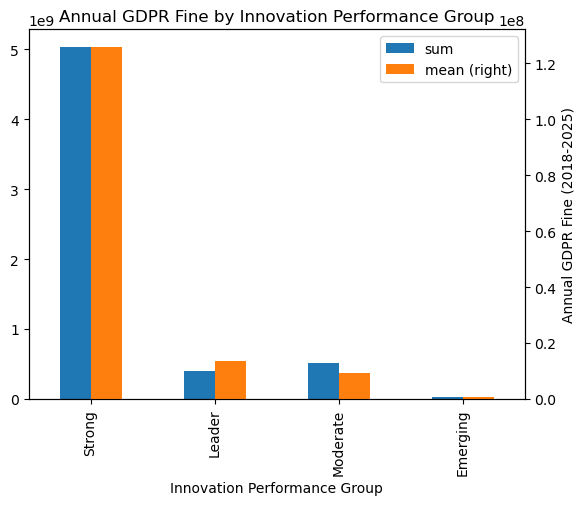

In [33]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
import matplotlib.pyplot as plt

df_descr_fine_innovation[["sum", "mean"]].head(4).sort_values(by="mean", ascending=False).plot(kind="bar", ylabel= "Annual GDPR Fine (2018-2025)", xlabel="Innovation Performance Group", secondary_y="mean")
plt.title("Annual GDPR Fine by Innovation Performance Group")


## Scatter Plot
### Logarithmic Scale

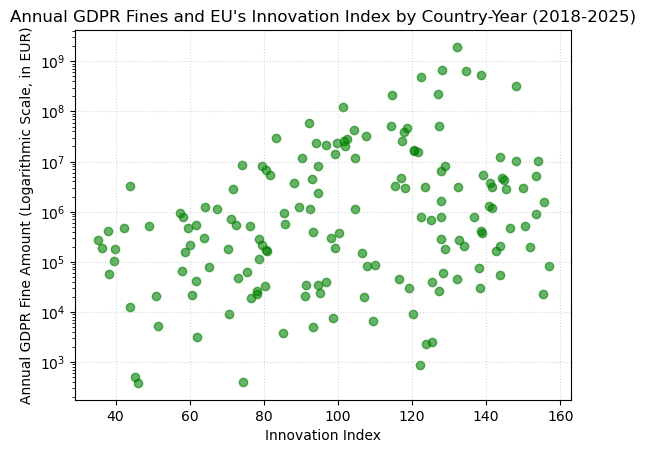

In [34]:
# Plot 2: Customized scatter plot of primary policy variables
import matplotlib.pyplot as plt

plt.scatter(df_merged["Innovation_Index"], df_merged["Fine"], color="green", alpha=0.6)
plt.yscale("log") # i used log scale to gain more insight into the variation
plt.xlabel("Innovation Index")
plt.ylabel("Annual GDPR Fine Amount (Logarithmic Scale, in EUR)")
plt.title("Annual GDPR Fines and EU's Innovation Index by Country-Year (2018-2025)")
plt.grid(True, linestyle=":", alpha = 0.5)
plt.show()

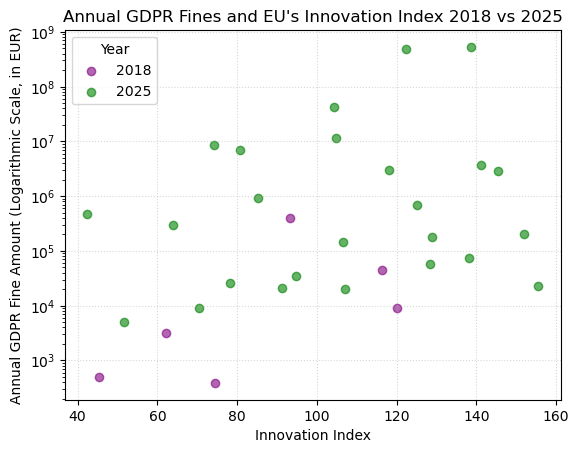

In [35]:
# Plot 2: Comparing innovation-GDPR fine relationship between 2018 (intro of GDPR) vs 2025 (most recent data)
import matplotlib.pyplot as plt

#Resetting index so column year is available
df_merged_year_comp = df_merged.reset_index()
df_merged_year_comp = df_merged_year_comp[df_merged_year_comp["Fine"] > 0]

# Establishing years and colours
years = [2018, 2025]
colors = ["purple", "green"]

for year, color in zip(years, colors): 
    df_year = df_merged_year_comp[df_merged_year_comp["Year"] == year]
    plt.scatter(df_year["Innovation_Index"], df_year["Fine"], color=color, alpha=0.6, label=str(year))

plt.yscale("log") # i used log scale to gain more insight into the variation
plt.xlabel("Innovation Index")
plt.ylabel("Annual GDPR Fine Amount (Logarithmic Scale, in EUR)")
plt.title("Annual GDPR Fines and EU's Innovation Index 2018 vs 2025")
plt.grid(True, linestyle=":", alpha = 0.5)
plt.legend(title="Year")
plt.show()

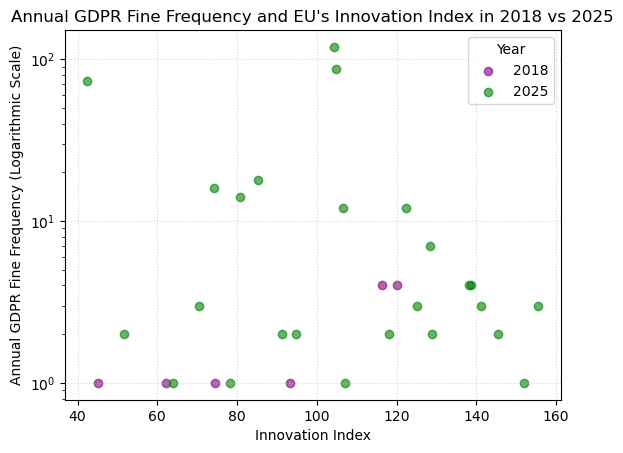

In [36]:
# Plot 2: Comparing innovation-GDPR fine frequency relationship between 2018 (intro of GDPR) and 2025 (most recent data)
import matplotlib.pyplot as plt

#Resetting index so column year is available
df_merged_year_comp = df_merged.reset_index()
df_merged_year_comp = df_merged_year_comp[df_merged_year_comp["Fine_Count"] > 0]

# Establishing years and colours
years = [2018, 2025]
colors = ["purple", "green"]

for year, color in zip(years, colors): 
    df_year = df_merged_year_comp[df_merged_year_comp["Year"] == year]
    plt.scatter(df_year["Innovation_Index"], df_year["Fine_Count"], color=color, alpha=0.6, label=str(year))

plt.yscale("log") # i used log scale to gain more insight into the variation
plt.xlabel("Innovation Index")
plt.ylabel("Annual GDPR Fine Frequency (Logarithmic Scale)")
plt.title("Annual GDPR Fine Frequency and EU's Innovation Index in 2018 vs 2025")
plt.grid(True, linestyle=":", alpha = 0.5)
plt.legend(title="Year")
plt.show()

## Regression # 1
### Level to Level

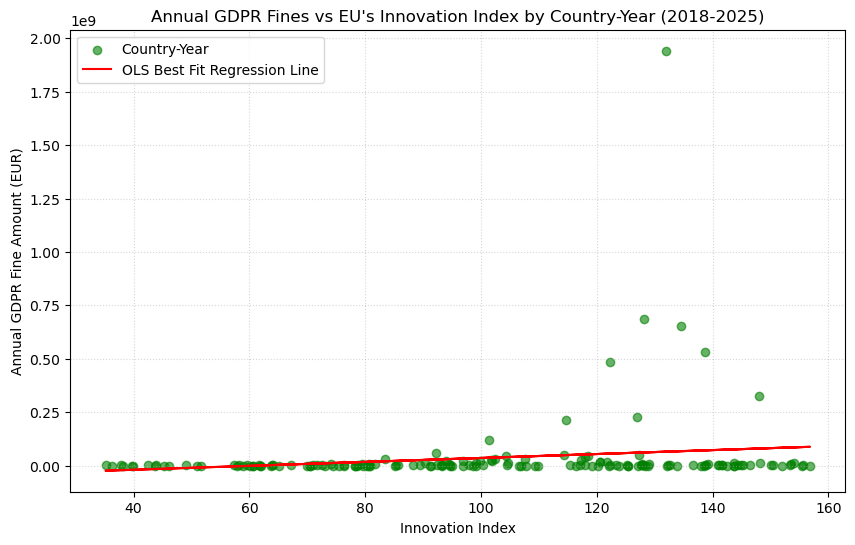

In [37]:
# Fit a simple linear regression and overlay the line of best fit

# Regression 1 - Innovation Index to Annual GDPR Fine (Level to level) 

import matplotlib.pyplot as plt
import statsmodels.api as sm

# Fitting the regression line
x_real = df_merged["Innovation_Index"]
y_real = df_merged["Fine"]
x_real_const = sm.add_constant(x_real)

model_real = sm.OLS(y_real, x_real_const).fit()

plt.figure(figsize=(10, 6))

# X is Innovation Index, Y is Fine amount
plt.scatter(df_merged["Innovation_Index"], df_merged["Fine"], color="green", alpha=0.6, label="Country-Year")

intercept_real, slope_real = model_real.params.iloc[0],model_real.params.iloc[1]

# Matching regression line to x values
plt.plot(df_merged["Innovation_Index"], intercept_real + slope_real * df_merged["Innovation_Index"], color="red", label="OLS Best Fit Regression Line")

# Labeled axes
plt.xlabel("Innovation Index")
plt.ylabel("Annual GDPR Fine Amount (EUR)")
plt.title("Annual GDPR Fines vs EU's Innovation Index by Country-Year (2018-2025)")

plt.legend()
plt.grid(True, linestyle=":", alpha = 0.5)
plt.show()

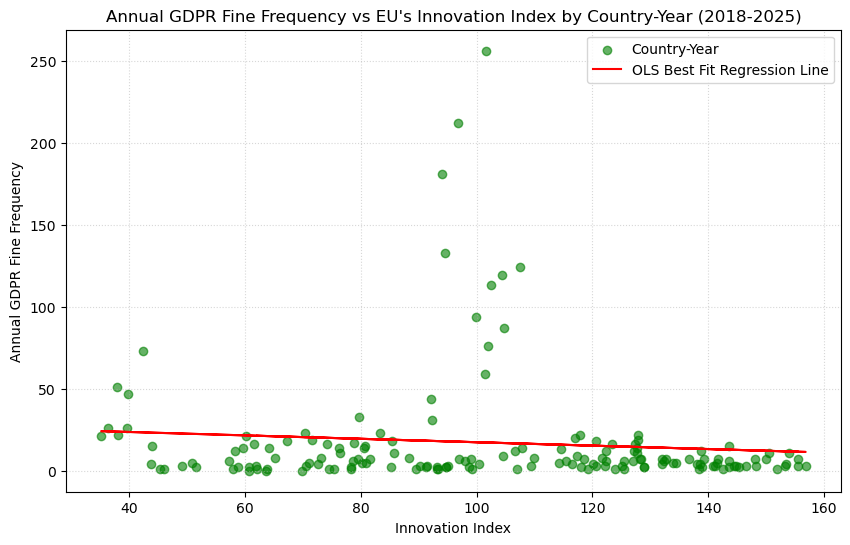

In [38]:
# Fit a simple linear regression and overlay the line of best fit

# Regression 1 - Innovation Index to Annual GDPR Fine Frequency (Level to level) 

import matplotlib.pyplot as plt
import statsmodels.api as sm

# Fitting the regression line
x_real = df_merged["Innovation_Index"]
y_real = df_merged["Fine_Count"]
x_real_const = sm.add_constant(x_real)

model_real = sm.OLS(y_real, x_real_const).fit()

plt.figure(figsize=(10, 6))

# X is Innovation Index, Y is Fine Count
plt.scatter(df_merged["Innovation_Index"], df_merged["Fine_Count"], color="green", alpha=0.6, label="Country-Year")

intercept_real, slope_real = model_real.params.iloc[0],model_real.params.iloc[1]

# Matching regression line to x values
plt.plot(df_merged["Innovation_Index"], intercept_real + slope_real * df_merged["Innovation_Index"], color="red", label="OLS Best Fit Regression Line")

# Labeled axes
plt.xlabel("Innovation Index")
plt.ylabel("Annual GDPR Fine Frequency")
plt.title("Annual GDPR Fine Frequency vs EU's Innovation Index by Country-Year (2018-2025)")

plt.legend()
plt.grid(True, linestyle=":", alpha = 0.5)
plt.show()

## Regression # 2
### Log to Level

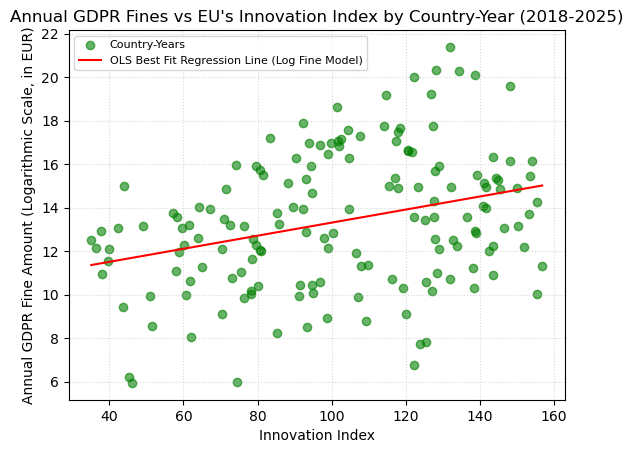

In [39]:
# Regression 2 - Log to Level 

import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

# Will be using log scale -> removing fines that = 0
df_merged_positive_fines = df_merged[df_merged["Fine"] > 0].copy()

# Creating a new column of logged fines
df_merged_positive_fines["Fine_Log"] = np.log(df_merged_positive_fines["Fine"])

# Sort data for clean regression line
df_merged_positive_fines = df_merged_positive_fines.sort_values("Innovation_Index")

# X is Innovation Index, Y is Logged Fine amount
plt.scatter(df_merged_positive_fines["Innovation_Index"], df_merged_positive_fines["Fine_Log"], color="green", alpha=0.6, label="Country-Years")

# Log to Level Regression
model_log_level = sm.OLS(df_merged_positive_fines["Fine_Log"], sm.add_constant(df_merged_positive_fines["Innovation_Index"])).fit()

# Matching regression line to x values
plt.plot(df_merged_positive_fines["Innovation_Index"],model_log_level.params.iloc[0] + model_log_level.params.iloc[1] * df_merged_positive_fines["Innovation_Index"], color="red", label="OLS Best Fit Regression Line (Log Fine Model)")

# Labeled axes
plt.xlabel("Innovation Index")
plt.ylabel("Annual GDPR Fine Amount (Logarithmic Scale, in EUR)")
plt.title("Annual GDPR Fines vs EU's Innovation Index by Country-Year (2018-2025)")

plt.legend(fontsize=8)
plt.grid(True, linestyle=":", alpha = 0.5)
plt.show()

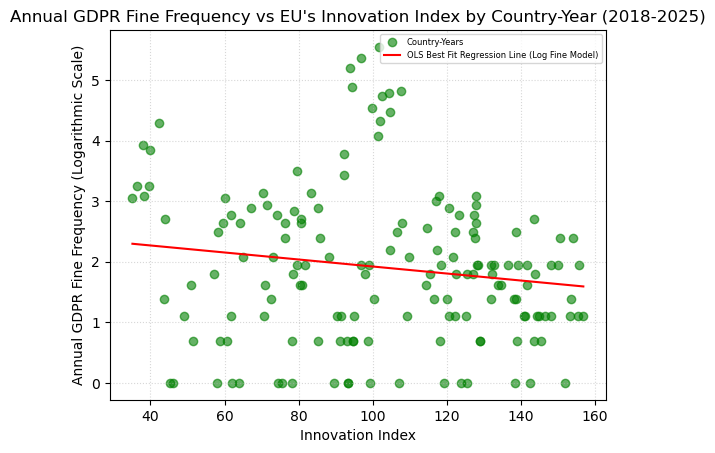

In [40]:
# Regression 1 - Innovation Index to Annual GDPR Fine Frequency
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

# Will be using log scale -> removing fines that = 0
df_merged_positive_fines = df_merged[df_merged["Fine_Count"] > 0].copy()

# Creating a new column of logged fines
df_merged_positive_fines["Fine_Count_Log"] = np.log(df_merged_positive_fines["Fine_Count"])

# Sort data for clean regression line
df_merged_positive_fines = df_merged_positive_fines.sort_values("Innovation_Index")

# X is Innovation Index, Y is Logged Fine amount
plt.scatter(df_merged_positive_fines["Innovation_Index"], df_merged_positive_fines["Fine_Count_Log"], color="green", alpha=0.6, label="Country-Years")

# Log to Level Regression
model_log_level = sm.OLS(df_merged_positive_fines["Fine_Count_Log"], sm.add_constant(df_merged_positive_fines["Innovation_Index"])).fit()

# Matching regression line to x values
plt.plot(df_merged_positive_fines["Innovation_Index"],model_log_level.params.iloc[0] + model_log_level.params.iloc[1] * df_merged_positive_fines["Innovation_Index"], color="red", label="OLS Best Fit Regression Line (Log Fine Model)")

# Labeled axes
plt.xlabel("Innovation Index")
plt.ylabel("Annual GDPR Fine Frequency (Logarithmic Scale)")
plt.title("Annual GDPR Fine Frequency vs EU's Innovation Index by Country-Year (2018-2025)")

plt.legend(fontsize=6)
plt.grid(True, linestyle=":", alpha = 0.5)
plt.show()

## Regression # 3 - Comparative
### Log to Level

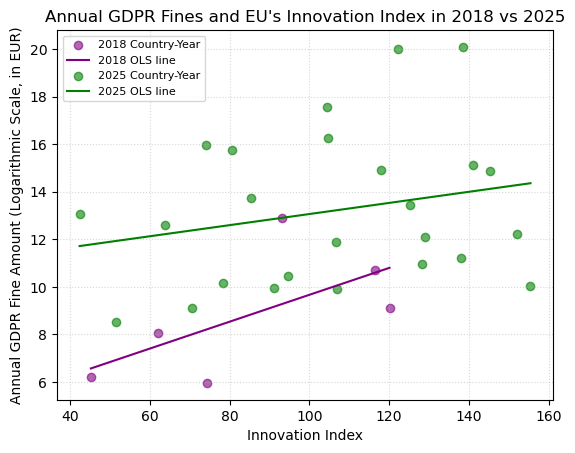

In [41]:
# Comparative Regression 3: Comparing innovation-GDPR fine relationship between 2018 (INTRODUCTION OF GDPR) and 2025 (current)
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

#Resetting index so column year is available
df_merged_positive_fines = df_merged.reset_index()
df_merged_positive_fines = df_merged_positive_fines[df_merged_positive_fines["Year"].isin([2018, 2025])]

df_merged_positive_fines["Fine_Log"] = np.log(df_merged_positive_fines["Fine"])

# Establishing years and colours
years = [2018, 2025]
colors = ["purple", "green"]

for year, color in zip(years, colors): 
    df_year = df_merged_positive_fines[df_merged_positive_fines["Year"] == year].sort_values("Innovation_Index")
    plt.scatter(df_year["Innovation_Index"], df_year["Fine_Log"], color=color, alpha=0.6, label=f"{year} Country-Year")

    model_year = sm.OLS(df_year["Fine_Log"], sm.add_constant(df_year["Innovation_Index"])).fit()
    plt.plot(df_year["Innovation_Index"], model_year.params.iloc[0] + model_year.params.iloc[1] * df_year["Innovation_Index"], color=color, label=f"{year} OLS line")


plt.xlabel("Innovation Index")
plt.ylabel("Annual GDPR Fine Amount (Logarithmic Scale, in EUR)")
plt.title("Annual GDPR Fines and EU's Innovation Index in 2018 vs 2025")
plt.grid(True, linestyle=":", alpha = 0.5)

plt.legend(fontsize=8)
plt.grid(True, linestyle=":", alpha = 0.5)
plt.show()

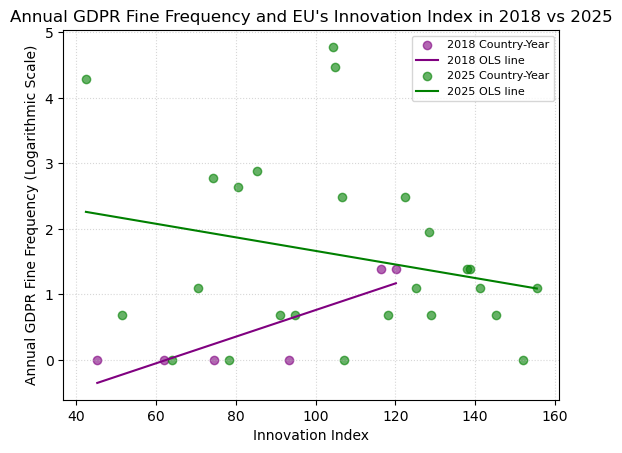

In [42]:
# Comparative Regression 3: Comparing innovation-GDPR fine frequency relationship between 2018 (INTRODUCTION OF GDPR) and 2025 (current)
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

#Resetting index so column year is available
df_merged_positive_fines = df_merged.reset_index()
df_merged_positive_fines = df_merged_positive_fines[df_merged_positive_fines["Year"].isin([2018, 2025])]

df_merged_positive_fines["Fine_Count_Log"] = np.log(df_merged_positive_fines["Fine_Count"])

# Establishing years and colours
years = [2018, 2025]
colors = ["purple", "green"]

for year, color in zip(years, colors): 
    df_year = df_merged_positive_fines[df_merged_positive_fines["Year"] == year].sort_values("Innovation_Index")
    plt.scatter(df_year["Innovation_Index"], df_year["Fine_Count_Log"], color=color, alpha=0.6, label=f"{year} Country-Year")

    model_year = sm.OLS(df_year["Fine_Count_Log"], sm.add_constant(df_year["Innovation_Index"])).fit()
    plt.plot(df_year["Innovation_Index"], model_year.params.iloc[0] + model_year.params.iloc[1] * df_year["Innovation_Index"], color=color, label=f"{year} OLS line")


plt.xlabel("Innovation Index")
plt.ylabel("Annual GDPR Fine Frequency (Logarithmic Scale)")
plt.title("Annual GDPR Fine Frequency and EU's Innovation Index in 2018 vs 2025")
plt.grid(True, linestyle=":", alpha = 0.5)

plt.legend(fontsize=8)
plt.grid(True, linestyle=":", alpha = 0.5)
plt.show()

- *Extra Credit: Write your visualization and regression interpretations here*

---

## **Results**

### **Research Background**

When studying data privacy and,specifically, GDPR, I have heard many companies and some governments (US) bring up regulation vs innovation, and how GDPR specifically stifles innovation of companies and countries (hence, US not having a Federal privacy legislation). I wanted to visualise this dependancy with the help of data: *do countries that fine the most have lower levels of innovation? Is there a correlation between GDPR and the level of innovation?*

Of course, this doesn't prove much and I would have had to look at EU business innovation index but I looked at the overall (summary) innovation index, not looking at specific industries or business types/sizes.

### **Important Definitions & Clarifications**:
1. **Innovation Index** is a comparative assessment of the research and innovation performance of EU Member States, other European countries, and global competitors from 2018 to 2025.

For this analysis I picked the summary innovation index (SII) as it covers innovation of EU as a whole. SII is calculated based on 32 indicators capturing a broad range of activities and factors related to innovation.

The score of SII ranges from 0 to 160 (least to best). The countries are divided into the following 4 goups (from strongest to weakest innovators):
- Leader
- Strong
- Moderate
- Emerging

As of 2025, the leaders are:
- Sweden
- Denmark
- Netherlands
- Finland

2. **GDPR fines are grouped by EU country and year**

Regression shows the GDPR fines issued by each country (27) per each year (2018 - 2025)


### **Analysis**
#### **Annual GDPR Fines vs EU Innovation Index (2018 to 2025)**

Countries with higher innovation index levy higher GDPR fines:

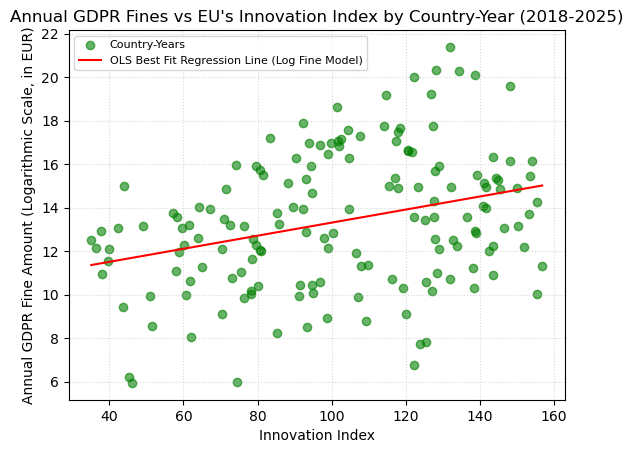

---

At the same time, the fine frequency increases in countries with lower innovation score:

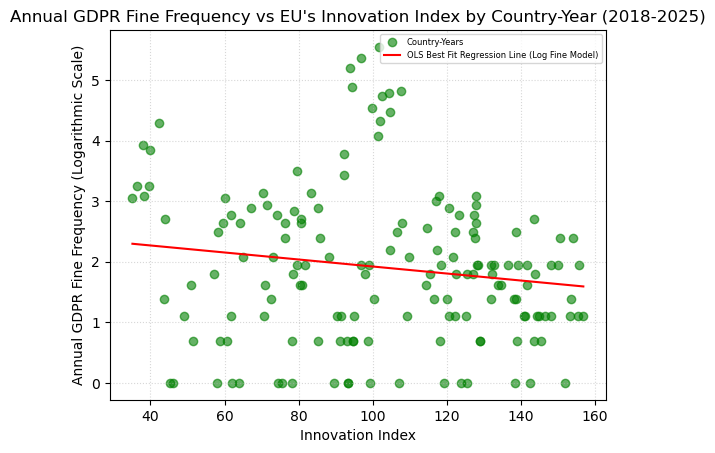

---

#### **Annual GDPR Fines vs EU Innovation Index - Comparing 2018 to 2025**

I compare 2018 to 2025 to see fine amount and frequency by the level of innovation of countries. GDPR was introduced in 2018 and I wanted to analyse the pattern of GDPR legislation in countries with high vs low level of innovation, and how it may have changed.

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Year</th>
      <th>Group</th>
      <th>Min</th>
      <th>Max</th>
      <th>countries</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>1</th>
      <td>2018</td>
      <td>Emerging</td>
      <td>34.163224</td>
      <td>69.987906</td>
      <td>Bulgaria, Croatia, Greece, Hungary, Latvia, Poland, Romania, Slovakia</td>
    </tr>
    <tr>
      <th>3</th>
      <td>2018</td>
      <td>Moderate</td>
      <td>73.764625</td>
      <td>93.198535</td>
      <td>Cyprus, Czech Republic, Estonia, Italy, Lithuania, Malta, Portugal, Slovenia, Spain</td>
    </tr> 
    <tr>
      <th>4</th>
      <td>2018</td>
      <td>Strong</td>
      <td>114.855808</td>
      <td>120.118456</td>
      <td>Austria, France, Germany</td>
    </tr>
    <tr>
      <th>2</th>
      <td>2018</td>
      <td>Leader</td>
      <td>125.293812</td>
      <td>142.513622</td>
      <td>Belgium, Denmark, Finland, Ireland, Luxembourg, Sweden, The Netherlands</td>
    </tr>
    <tr>
      <th>6</th>
      <td>2025</td>
      <td>Emerging</td>
      <td>42.395964</td>
      <td>78.250322</td>
      <td>Bulgaria, Hungary, Latvia, Poland, Romania, Slovakia</td>
    </tr>
    <tr>
      <th>8</th>
      <td>2025</td>
      <td>Moderate</td>
      <td>80.612213</td>
      <td>106.983955</td>
      <td>Croatia, Cyprus, Czech Republic, Greece, Italy, Lithuania, Malta, Portugal, Slovenia, Spain</td>
    </tr>
    <tr>
      <th>9</th>
      <td>2025</td>
      <td>Strong</td>
      <td>118.016453</td>
      <td>138.632143</td>
      <td>Austria, Belgium, Estonia, France, Germany, Ireland, Luxembourg</td>
    </tr>
    <tr>
      <th>7</th>
      <td>2025</td>
      <td>Leader</td>
      <td>141.129185</td>
      <td>155.456410</td>
      <td>Denmark, Finland, Sweden, The Netherlands</td>
    </tr>
  </tbody>
</table>
</div>

When the GDPR was first introduced in 2018, majority of fines came from moderate to strong innovator countries, with  leaders not issuing any fines at all. 2025 also shows a positive correlation, now with leaders in innovation issuing the highest fines.

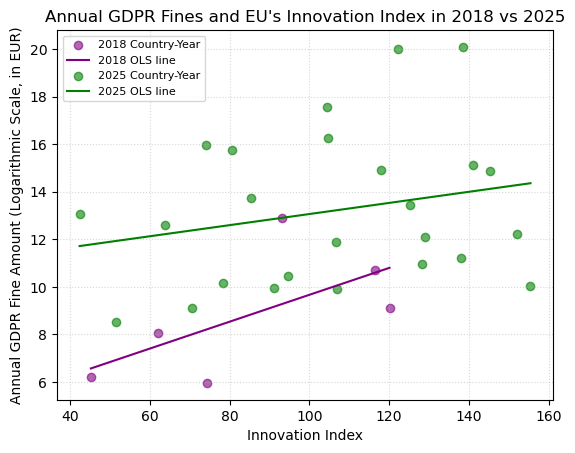 

---

In terms of frequency, the trend for 2018 is similar to the fine amount in the analysis above. However, 2025 shows a negative correlation between fine frequency and the level of innovation: countries with higher innovation scores issue less fines. One potential explanation could be that because those countries' fines are much higher, the companies are brought into compliance faster.

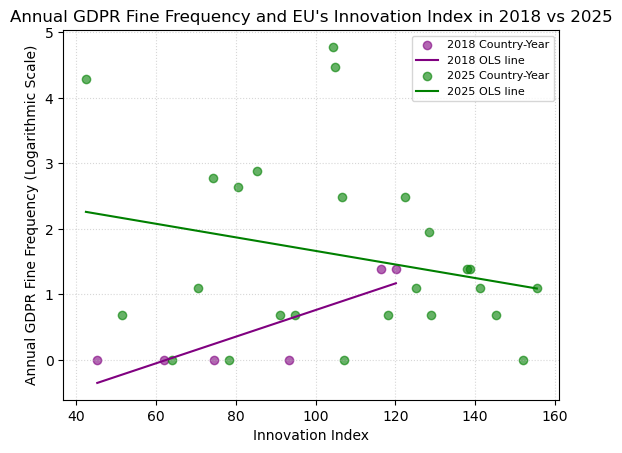

### **A few caveats**

- This analysis doesn't consider the origin of companies against which the fines are levied, so while the innovation level of the country issuing the fine is not impacted, that company's country's innovation may be. Considering the fact that the biggest GDPR-related fines are issued against US-based tech giants, it would be interesting to compare those fines against US innovation index (or China).
- For more accurate analysis, a more specific innovation index needs to be considered. The index utilised here is a Summary Innovation Index - a mix of multiple innovation-related indexes.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.